# Machine Learning-Based Phishing URL Detection

## Direct URL Prediction System

**Student ID:** S25021953  
**Module:** COM763 Advanced Machine Learning

This notebook develops an improved phishing detection system that accepts a complete URL as input. Unlike the original prototype, which required users to enter feature values manually, this version automatically extracts lexical and structural features from the URL before classification.

The workflow includes dataset loading, exploratory analysis, URL-based feature selection, model training, evaluation, model comparison and deployment file generation.

In [1]:
# Core data-handling libraries
import pandas as pd
import numpy as np

# Visualisation libraries
import matplotlib.pyplot as plt

# URL-processing libraries
from urllib.parse import urlparse
import ipaddress
import re

# Machine-learning libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# Model saving
import pickle
import time
import warnings

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
from google.colab import files
import io

# Upload the original full PhiUSIIL dataset
uploaded = files.upload()

file_name = list(uploaded.keys())[0]

df = pd.read_csv(io.BytesIO(uploaded[file_name]))

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)

df.head()

Saving PhiUSIIL_Phishing_URL_Dataset.csv to PhiUSIIL_Phishing_URL_Dataset.csv
Dataset loaded successfully.
Dataset shape: (235795, 56)


,FILENAME,URL,URLLength,Domain,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
0,521848.txt,https://www.southbankmosaics.com,31,www.southbankmosaics.com,24,0,com,100.0,1.000000,0.522907,...,0,0,1,34,20,28,119,0,124,1
1,31372.txt,https://www.uni-mainz.de,23,www.uni-mainz.de,16,0,de,100.0,0.666667,0.032650,...,0,0,1,50,9,8,39,0,217,1
2,597387.txt,https://www.voicefmradio.co.uk,29,www.voicefmradio.co.uk,22,0,uk,100.0,0.866667,0.028555,...,0,0,1,10,2,7,42,2,5,1
3,554095.txt,https://www.sfnmjournal.com,26,www.sfnmjournal.com,19,0,com,100.0,1.000000,0.522907,...,1,1,1,3,27,15,22,1,31,1
4,151578.txt,https://www.rewildingargentina.org,33,www.rewildingargentina.org,26,0,org,100.0,1.000000,0.079963,...,1,0,1,244,15,34,72,1,85,1


In [3]:
print("Dataset columns:\n")

for index, column in enumerate(df.columns, start=1):
    print(f"{index}. {column}")

Dataset columns:

1. FILENAME
2. URL
3. URLLength
4. Domain
5. DomainLength
6. IsDomainIP
7. TLD
8. URLSimilarityIndex
9. CharContinuationRate
10. TLDLegitimateProb
11. URLCharProb
12. TLDLength
13. NoOfSubDomain
14. HasObfuscation
15. NoOfObfuscatedChar
16. ObfuscationRatio
17. NoOfLettersInURL
18. LetterRatioInURL
19. NoOfDegitsInURL
20. DegitRatioInURL
21. NoOfEqualsInURL
22. NoOfQMarkInURL
23. NoOfAmpersandInURL
24. NoOfOtherSpecialCharsInURL
25. SpacialCharRatioInURL
26. IsHTTPS
27. LineOfCode
28. LargestLineLength
29. HasTitle
30. Title
31. DomainTitleMatchScore
32. URLTitleMatchScore
33. HasFavicon
34. Robots
35. IsResponsive
36. NoOfURLRedirect
37. NoOfSelfRedirect
38. HasDescription
39. NoOfPopup
40. NoOfiFrame
41. HasExternalFormSubmit
42. HasSocialNet
43. HasSubmitButton
44. HasHiddenFields
45. HasPasswordField
46. Bank
47. Pay
48. Crypto
49. HasCopyrightInfo
50. NoOfImage
51. NoOfCSS
52. NoOfJS
53. NoOfSelfRef
54. NoOfEmptyRef
55. NoOfExternalRef
56. label


##URL-Based Feature Selection

The original dataset contains both URL-level features and webpage-content features. Webpage-content features require downloading and inspecting a live website, which could introduce security risks, network delays and deployment failures.

Therefore, this improved system uses only lexical and structural characteristics that can be calculated directly from the submitted URL. This ensures that the same feature-generation process is used during both model training and Streamlit prediction.

In [4]:
# Features that can be extracted directly from a pasted URL
url_features = [
    "URLLength",
    "DomainLength",
    "IsDomainIP",
    "TLDLength",
    "NoOfSubDomain",
    "HasObfuscation",
    "NoOfObfuscatedChar",
    "ObfuscationRatio",
    "NoOfLettersInURL",
    "LetterRatioInURL",
    "NoOfDegitsInURL",
    "DegitRatioInURL",
    "NoOfEqualsInURL",
    "NoOfQMarkInURL",
    "NoOfAmpersandInURL",
    "NoOfOtherSpecialCharsInURL",
    "SpacialCharRatioInURL",
    "IsHTTPS"
]

target_column = "label"

# Confirm that all selected columns exist
missing_columns = [
    column for column in url_features
    if column not in df.columns
]

if missing_columns:
    print("Missing columns:", missing_columns)
else:
    print("All selected URL features are available.")

print("\nNumber of selected features:", len(url_features))
print("\nSelected features:")

for feature in url_features:
    print("-", feature)

All selected URL features are available.

Number of selected features: 18

Selected features:
- URLLength
- DomainLength
- IsDomainIP
- TLDLength
- NoOfSubDomain
- HasObfuscation
- NoOfObfuscatedChar
- ObfuscationRatio
- NoOfLettersInURL
- LetterRatioInURL
- NoOfDegitsInURL
- DegitRatioInURL
- NoOfEqualsInURL
- NoOfQMarkInURL
- NoOfAmpersandInURL
- NoOfOtherSpecialCharsInURL
- SpacialCharRatioInURL
- IsHTTPS


In [5]:
# Create the machine-learning feature matrix and target vector
X = df[url_features].copy()
y = df[target_column].copy()

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

print("\nFeature data types:")
print(X.dtypes)

print("\nMissing values in selected features:")
print(X.isnull().sum())

X.head()

Feature matrix shape: (235795, 18)
Target vector shape: (235795,)

Feature data types:
URLLength                       int64
DomainLength                    int64
IsDomainIP                      int64
TLDLength                       int64
NoOfSubDomain                   int64
HasObfuscation                  int64
NoOfObfuscatedChar              int64
ObfuscationRatio              float64
NoOfLettersInURL                int64
LetterRatioInURL              float64
NoOfDegitsInURL                 int64
DegitRatioInURL               float64
NoOfEqualsInURL                 int64
NoOfQMarkInURL                  int64
NoOfAmpersandInURL              int64
NoOfOtherSpecialCharsInURL      int64
SpacialCharRatioInURL         float64
IsHTTPS                         int64
dtype: object

Missing values in selected features:
URLLength                     0
DomainLength                  0
IsDomainIP                    0
TLDLength                     0
NoOfSubDomain                 0
HasObfuscation   

,URLLength,DomainLength,IsDomainIP,TLDLength,NoOfSubDomain,HasObfuscation,NoOfObfuscatedChar,ObfuscationRatio,NoOfLettersInURL,LetterRatioInURL,NoOfDegitsInURL,DegitRatioInURL,NoOfEqualsInURL,NoOfQMarkInURL,NoOfAmpersandInURL,NoOfOtherSpecialCharsInURL,SpacialCharRatioInURL,IsHTTPS
0,31,24,0,3,1,0,0,0.0,18,0.581,0,0.0,0,0,0,1,0.032,1
1,23,16,0,2,1,0,0,0.0,9,0.391,0,0.0,0,0,0,2,0.087,1
2,29,22,0,2,2,0,0,0.0,15,0.517,0,0.0,0,0,0,2,0.069,1
3,26,19,0,3,1,0,0,0.0,13,0.500,0,0.0,0,0,0,1,0.038,1
4,33,26,0,3,1,0,0,0.0,20,0.606,0,0.0,0,0,0,1,0.030,1


In [6]:
# Descriptive statistics of the selected URL features
X.describe().T

,count,mean,std,min,25%,50%,75%,max
URLLength,235795.0,34.573095,41.314153,13.0,23.000,27.000,34.000,6097.000
DomainLength,235795.0,21.470396,9.150793,4.0,16.000,20.000,24.000,110.000
IsDomainIP,235795.0,0.002706,0.051946,0.0,0.000,0.000,0.000,1.000
TLDLength,235795.0,2.764456,0.599739,2.0,2.000,3.000,3.000,13.000
NoOfSubDomain,235795.0,1.164758,0.600969,0.0,1.000,1.000,1.000,10.000
HasObfuscation,235795.0,0.002057,0.045306,0.0,0.000,0.000,0.000,1.000
NoOfObfuscatedChar,235795.0,0.024861,1.876249,0.0,0.000,0.000,0.000,447.000
ObfuscationRatio,235795.0,0.000138,0.003817,0.0,0.000,0.000,0.000,0.348
NoOfLettersInURL,235795.0,19.428919,29.090330,0.0,10.000,14.000,20.000,5191.000
LetterRatioInURL,235795.0,0.515946,0.123315,0.0,0.435,0.519,0.594,0.926


In [7]:
# Display class counts and percentages
class_summary = pd.DataFrame({
    "Count": y.value_counts().sort_index(),
    "Percentage": (
        y.value_counts(normalize=True).sort_index() * 100
    ).round(2)
})

class_summary.index = ["Phishing (0)", "Legitimate (1)"]

class_summary

,Count,Percentage
Phishing (0),100945,42.81
Legitimate (1),134850,57.19


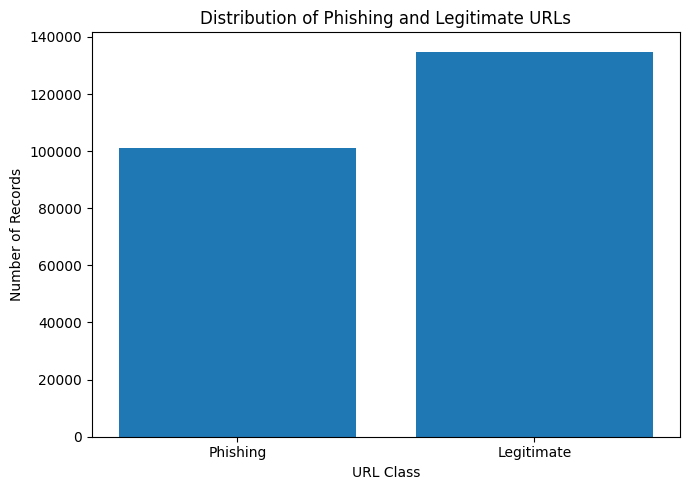

In [8]:
# Plot the target-class distribution
class_counts = y.value_counts().sort_index()

plt.figure(figsize=(7, 5))
plt.bar(
    ["Phishing", "Legitimate"],
    class_counts.values
)

plt.title("Distribution of Phishing and Legitimate URLs")
plt.xlabel("URL Class")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()

In [9]:
# Calculate correlations with the target variable
correlation_data = df[url_features + [target_column]].corr()

target_correlations = (
    correlation_data[target_column]
    .drop(target_column)
    .sort_values(key=abs, ascending=False)
)

print("Selected-feature correlations with the target:\n")
print(target_correlations)

Selected-feature correlations with the target:

IsHTTPS                       0.609132
SpacialCharRatioInURL        -0.533537
DegitRatioInURL              -0.432032
LetterRatioInURL             -0.367794
NoOfOtherSpecialCharsInURL   -0.358891
DomainLength                 -0.283152
NoOfLettersInURL             -0.258090
URLLength                    -0.233445
NoOfDegitsInURL              -0.177980
NoOfQMarkInURL               -0.175621
TLDLength                    -0.079159
NoOfEqualsInURL              -0.076963
IsDomainIP                   -0.060202
HasObfuscation               -0.052473
ObfuscationRatio             -0.041915
NoOfAmpersandInURL           -0.034622
NoOfObfuscatedChar           -0.015315
NoOfSubDomain                -0.005955
Name: label, dtype: float64


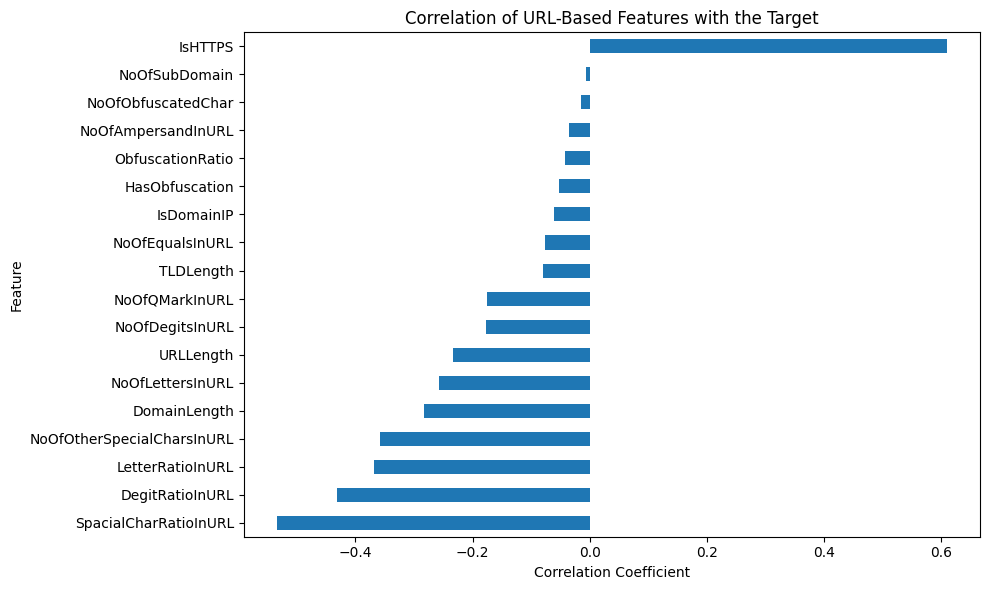

In [10]:
plt.figure(figsize=(10, 6))

target_correlations.sort_values().plot(kind="barh")

plt.title("Correlation of URL-Based Features with the Target")
plt.xlabel("Correlation Coefficient")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [12]:
def normalise_url(url):
    """
    Clean and normalise a user-submitted URL.

    If the scheme is missing, HTTPS is added temporarily so that
    urllib can parse the domain correctly.
    """
    if not isinstance(url, str):
        raise TypeError("The URL must be provided as text.")

    url = url.strip()

    if not url:
        raise ValueError("The URL cannot be empty.")

    if not re.match(r"^[a-zA-Z][a-zA-Z0-9+.-]*://", url):
        url = "https://" + url

    return url


def check_domain_ip(domain):
    """
    Return 1 when the domain is an IPv4 or IPv6 address;
    otherwise return 0.
    """
    clean_domain = domain.split(":")[0].strip("[]")

    try:
        ipaddress.ip_address(clean_domain)
        return 1
    except ValueError:
        return 0


def extract_url_features(url):
    """
    Extract lexical and structural features from a complete URL.

    The returned feature names and order match the features used
    to train the machine-learning models.
    """
    normalised_url = normalise_url(url)
    parsed_url = urlparse(normalised_url)

    domain = parsed_url.hostname or ""
    domain_without_www = re.sub(
        r"^www\.",
        "",
        domain,
        flags=re.IGNORECASE
    )

    # Extract the final domain component as the TLD
    domain_parts = [
        part for part in domain_without_www.split(".")
        if part
    ]

    tld = domain_parts[-1] if len(domain_parts) >= 2 else ""

    # Count subdomains, excluding the main domain and TLD
    number_of_subdomains = max(len(domain_parts) - 2, 0)

    url_length = len(normalised_url)
    domain_length = len(domain)

    number_of_letters = sum(
        character.isalpha()
        for character in normalised_url
    )

    number_of_digits = sum(
        character.isdigit()
        for character in normalised_url
    )

    number_of_equals = normalised_url.count("=")
    number_of_question_marks = normalised_url.count("?")
    number_of_ampersands = normalised_url.count("&")

    # Percent encoding is treated as URL obfuscation
    obfuscated_sequences = re.findall(
        r"%[0-9A-Fa-f]{2}",
        normalised_url
    )

    number_of_obfuscated_characters = len(obfuscated_sequences)
    has_obfuscation = int(
        number_of_obfuscated_characters > 0
    )

    # Count special characters other than =, ? and &
    excluded_special_characters = {"=", "?", "&"}

    number_of_other_special_characters = sum(
        not character.isalnum()
        and character not in excluded_special_characters
        for character in normalised_url
    )

    features = {
        "URLLength": url_length,
        "DomainLength": domain_length,
        "IsDomainIP": check_domain_ip(domain),
        "TLDLength": len(tld),
        "NoOfSubDomain": number_of_subdomains,
        "HasObfuscation": has_obfuscation,
        "NoOfObfuscatedChar": number_of_obfuscated_characters,
        "ObfuscationRatio": (
            number_of_obfuscated_characters / url_length
            if url_length else 0
        ),
        "NoOfLettersInURL": number_of_letters,
        "LetterRatioInURL": (
            number_of_letters / url_length
            if url_length else 0
        ),
        "NoOfDegitsInURL": number_of_digits,
        "DegitRatioInURL": (
            number_of_digits / url_length
            if url_length else 0
        ),
        "NoOfEqualsInURL": number_of_equals,
        "NoOfQMarkInURL": number_of_question_marks,
        "NoOfAmpersandInURL": number_of_ampersands,
        "NoOfOtherSpecialCharsInURL":
            number_of_other_special_characters,
        "SpacialCharRatioInURL": (
            number_of_other_special_characters / url_length
            if url_length else 0
        ),
        "IsHTTPS": int(
            parsed_url.scheme.lower() == "https"
        )
    }

    # Ensure that the output order exactly matches model training
    return pd.DataFrame(
        [[features[feature] for feature in url_features]],
        columns=url_features
    )

In [14]:
test_urls = [
    "https://www.google.com",
    "http://192.168.1.1/login",
    "www.microsoft.com"
]

for test_url in test_urls:
    print("\nURL:", test_url)
    display(extract_url_features(test_url))


URL: https://www.google.com


,URLLength,DomainLength,IsDomainIP,TLDLength,NoOfSubDomain,HasObfuscation,NoOfObfuscatedChar,ObfuscationRatio,NoOfLettersInURL,LetterRatioInURL,NoOfDegitsInURL,DegitRatioInURL,NoOfEqualsInURL,NoOfQMarkInURL,NoOfAmpersandInURL,NoOfOtherSpecialCharsInURL,SpacialCharRatioInURL,IsHTTPS
0,22,14,0,3,0,0,0,0.0,17,0.772727,0,0.0,0,0,0,5,0.227273,1



URL: http://192.168.1.1/login


,URLLength,DomainLength,IsDomainIP,TLDLength,NoOfSubDomain,HasObfuscation,NoOfObfuscatedChar,ObfuscationRatio,NoOfLettersInURL,LetterRatioInURL,NoOfDegitsInURL,DegitRatioInURL,NoOfEqualsInURL,NoOfQMarkInURL,NoOfAmpersandInURL,NoOfOtherSpecialCharsInURL,SpacialCharRatioInURL,IsHTTPS
0,24,11,1,1,2,0,0,0.0,9,0.375,8,0.333333,0,0,0,7,0.291667,0



URL: www.microsoft.com


,URLLength,DomainLength,IsDomainIP,TLDLength,NoOfSubDomain,HasObfuscation,NoOfObfuscatedChar,ObfuscationRatio,NoOfLettersInURL,LetterRatioInURL,NoOfDegitsInURL,DegitRatioInURL,NoOfEqualsInURL,NoOfQMarkInURL,NoOfAmpersandInURL,NoOfOtherSpecialCharsInURL,SpacialCharRatioInURL,IsHTTPS
0,25,17,0,3,0,0,0,0.0,20,0.8,0,0.0,0,0,0,5,0.2,1


In [15]:
# Compare generated features against dataset features
comparison_rows = []

for row_index in range(10):
    original_url = df.loc[row_index, "URL"]
    generated = extract_url_features(original_url).iloc[0]

    for feature in url_features:
        original_value = df.loc[row_index, feature]
        generated_value = generated[feature]

        comparison_rows.append({
            "Row": row_index,
            "Feature": feature,
            "Dataset Value": original_value,
            "Generated Value": generated_value,
            "Matches": np.isclose(
                original_value,
                generated_value,
                rtol=1e-5,
                atol=1e-5
            )
        })

comparison_df = pd.DataFrame(comparison_rows)

print("Overall matching percentage:")
print(
    round(comparison_df["Matches"].mean() * 100, 2),
    "%"
)

comparison_df[
    comparison_df["Matches"] == False
].head(30)

Overall matching percentage:
66.67 %


,Row,Feature,Dataset Value,Generated Value,Matches
0,0,URLLength,31.000,32.000000,False
4,0,NoOfSubDomain,1.000,0.000000,False
8,0,NoOfLettersInURL,18.000,27.000000,False
9,0,LetterRatioInURL,0.581,0.843750,False
15,0,NoOfOtherSpecialCharsInURL,1.000,5.000000,False
16,0,SpacialCharRatioInURL,0.032,0.156250,False
18,1,URLLength,23.000,24.000000,False
22,1,NoOfSubDomain,1.000,0.000000,False
26,1,NoOfLettersInURL,9.000,18.000000,False
27,1,LetterRatioInURL,0.391,0.750000,False


In [16]:
print("Overall matching percentage:")
print(f"{comparison_df['Matches'].mean() * 100:.2f}%")

print("\nFeatures with mismatches:")
mismatch_summary = (
    comparison_df[comparison_df["Matches"] == False]
    ["Feature"]
    .value_counts()
)

print(mismatch_summary)

Overall matching percentage:
66.67%

Features with mismatches:
Feature
URLLength                     10
NoOfSubDomain                 10
NoOfLettersInURL              10
LetterRatioInURL              10
NoOfOtherSpecialCharsInURL    10
SpacialCharRatioInURL         10
Name: count, dtype: int64


In [17]:
# Display exact differences for the first five dataset URLs
diagnostic_rows = []

for row_index in range(5):
    original_url = str(df.loc[row_index, "URL"])
    generated = extract_url_features(original_url).iloc[0]

    diagnostic_rows.append({
        "Row": row_index,
        "Original URL": original_url,
        "Dataset URLLength": df.loc[row_index, "URLLength"],
        "Python len(URL)": len(original_url),
        "Generated URLLength": generated["URLLength"],

        "Dataset Subdomains": df.loc[row_index, "NoOfSubDomain"],
        "Generated Subdomains": generated["NoOfSubDomain"],

        "Dataset Letters": df.loc[row_index, "NoOfLettersInURL"],
        "Generated Letters": generated["NoOfLettersInURL"],

        "Dataset Other Special": df.loc[
            row_index,
            "NoOfOtherSpecialCharsInURL"
        ],
        "Generated Other Special": generated[
            "NoOfOtherSpecialCharsInURL"
        ]
    })

diagnostic_df = pd.DataFrame(diagnostic_rows)

pd.set_option("display.max_colwidth", None)
display(diagnostic_df)

,Row,Original URL,Dataset URLLength,Python len(URL),Generated URLLength,Dataset Subdomains,Generated Subdomains,Dataset Letters,Generated Letters,Dataset Other Special,Generated Other Special
0,0,https://www.southbankmosaics.com,31,32,32.0,1,0.0,18,27.0,1,5.0
1,1,https://www.uni-mainz.de,23,24,24.0,1,0.0,9,18.0,2,6.0
2,2,https://www.voicefmradio.co.uk,29,30,30.0,2,1.0,15,24.0,2,6.0
3,3,https://www.sfnmjournal.com,26,27,27.0,1,0.0,13,22.0,1,5.0
4,4,https://www.rewildingargentina.org,33,34,34.0,1,0.0,20,29.0,1,5.0


In [18]:
for row_index in range(5):
    url = str(df.loc[row_index, "URL"])

    print("=" * 80)
    print("Row:", row_index)
    print("URL:", repr(url))
    print("Python URL length:", len(url))
    print("Dataset URL length:", df.loc[row_index, "URLLength"])
    print("Domain:", df.loc[row_index, "Domain"])
    print("Dataset subdomains:", df.loc[row_index, "NoOfSubDomain"])

Row: 0
URL: 'https://www.southbankmosaics.com'
Python URL length: 32
Dataset URL length: 31
Domain: www.southbankmosaics.com
Dataset subdomains: 1
Row: 1
URL: 'https://www.uni-mainz.de'
Python URL length: 24
Dataset URL length: 23
Domain: www.uni-mainz.de
Dataset subdomains: 1
Row: 2
URL: 'https://www.voicefmradio.co.uk'
Python URL length: 30
Dataset URL length: 29
Domain: www.voicefmradio.co.uk
Dataset subdomains: 2
Row: 3
URL: 'https://www.sfnmjournal.com'
Python URL length: 27
Dataset URL length: 26
Domain: www.sfnmjournal.com
Dataset subdomains: 1
Row: 4
URL: 'https://www.rewildingargentina.org'
Python URL length: 34
Dataset URL length: 33
Domain: www.rewildingargentina.org
Dataset subdomains: 1


In [22]:
def extract_url_features(url):
    """
    Extract lexical and structural features from a complete URL.

    The feature calculations are aligned with the PhiUSIIL
    dataset definitions observed through direct validation.
    """
    normalised_url = normalise_url(url)
    parsed_url = urlparse(normalised_url)

    domain = parsed_url.hostname or ""

    domain_parts = [
        part for part in domain.split(".")
        if part
    ]

    tld = domain_parts[-1] if len(domain_parts) >= 2 else ""

    # The dataset counts www as a subdomain
    number_of_subdomains = max(len(domain_parts) - 2, 0)

    # Dataset URLLength is consistently one less than Python len()
    url_length = max(len(normalised_url) - 1, 0)

    domain_length = len(domain)

    number_of_letters = sum(
        character.isalpha()
        for character in normalised_url
    )

    number_of_digits = sum(
        character.isdigit()
        for character in normalised_url
    )

    number_of_equals = normalised_url.count("=")
    number_of_question_marks = normalised_url.count("?")
    number_of_ampersands = normalised_url.count("&")

    obfuscated_sequences = re.findall(
        r"%[0-9A-Fa-f]{2}",
        normalised_url
    )

    number_of_obfuscated_characters = len(obfuscated_sequences)

    has_obfuscation = int(
        number_of_obfuscated_characters > 0
    )

    excluded_special_characters = {
        "=",
        "?",
        "&"
    }

    number_of_other_special_characters = sum(
        not character.isalnum()
        and character not in excluded_special_characters
        for character in normalised_url
    )

    features = {
        "URLLength": url_length,
        "DomainLength": domain_length,
        "IsDomainIP": check_domain_ip(domain),
        "TLDLength": len(tld),
        "NoOfSubDomain": number_of_subdomains,
        "HasObfuscation": has_obfuscation,
        "NoOfObfuscatedChar": number_of_obfuscated_characters,
        "ObfuscationRatio": (
            number_of_obfuscated_characters / url_length
            if url_length else 0
        ),
        "NoOfLettersInURL": number_of_letters,
        "LetterRatioInURL": (
            number_of_letters / url_length
            if url_length else 0
        ),
        "NoOfDegitsInURL": number_of_digits,
        "DegitRatioInURL": (
            number_of_digits / url_length
            if url_length else 0
        ),
        "NoOfEqualsInURL": number_of_equals,
        "NoOfQMarkInURL": number_of_question_marks,
        "NoOfAmpersandInURL": number_of_ampersands,
        "NoOfOtherSpecialCharsInURL":
            number_of_other_special_characters,
        "SpacialCharRatioInURL": (
            number_of_other_special_characters / url_length
            if url_length else 0
        ),
        "IsHTTPS": int(
            parsed_url.scheme.lower() == "https"
        )
    }

    return pd.DataFrame(
        [[features[feature] for feature in url_features]],
        columns=url_features
    )

In [24]:
# Compare generated features against the dataset values
comparison_rows = []

for row_index in range(10):
    original_url = str(df.loc[row_index, "URL"])

    generated_features = extract_url_features(
        original_url
    ).iloc[0]

    for feature in url_features:
        dataset_value = df.loc[
            row_index,
            feature
        ]

        generated_value = generated_features[
            feature
        ]

        comparison_rows.append({
            "Row": row_index,
            "URL": original_url,
            "Feature": feature,
            "Dataset Value": dataset_value,
            "Generated Value": generated_value,
            "Matches": np.isclose(
                dataset_value,
                generated_value,
                rtol=1e-5,
                atol=1e-5
            )
        })

comparison_df = pd.DataFrame(
    comparison_rows
)

print("Validation completed.")

display(
    comparison_df[
        comparison_df["Matches"] == False
    ].head(30)
)

Validation completed.


,Row,URL,Feature,Dataset Value,Generated Value,Matches
8,0,https://www.southbankmosaics.com,NoOfLettersInURL,18.000,27.000000,False
9,0,https://www.southbankmosaics.com,LetterRatioInURL,0.581,0.870968,False
15,0,https://www.southbankmosaics.com,NoOfOtherSpecialCharsInURL,1.000,5.000000,False
16,0,https://www.southbankmosaics.com,SpacialCharRatioInURL,0.032,0.161290,False
26,1,https://www.uni-mainz.de,NoOfLettersInURL,9.000,18.000000,False
27,1,https://www.uni-mainz.de,LetterRatioInURL,0.391,0.782609,False
33,1,https://www.uni-mainz.de,NoOfOtherSpecialCharsInURL,2.000,6.000000,False
34,1,https://www.uni-mainz.de,SpacialCharRatioInURL,0.087,0.260870,False
44,2,https://www.voicefmradio.co.uk,NoOfLettersInURL,15.000,24.000000,False
45,2,https://www.voicefmradio.co.uk,LetterRatioInURL,0.517,0.827586,False


In [25]:
# Calculate the overall matching percentage
matching_percentage = (
    comparison_df["Matches"].mean() * 100
)

print("Overall matching percentage:")
print(f"{matching_percentage:.2f}%")

print("\nFeatures with mismatches:")

mismatch_summary = (
    comparison_df[
        comparison_df["Matches"] == False
    ]["Feature"]
    .value_counts()
)

if mismatch_summary.empty:
    print("No mismatches found.")
else:
    print(mismatch_summary)

Overall matching percentage:
77.78%

Features with mismatches:
Feature
NoOfLettersInURL              10
LetterRatioInURL              10
NoOfOtherSpecialCharsInURL    10
SpacialCharRatioInURL         10
Name: count, dtype: int64


In [26]:
# Final URL features that can be reproduced consistently
url_features = [
    "URLLength",
    "DomainLength",
    "IsDomainIP",
    "TLDLength",
    "NoOfSubDomain",
    "HasObfuscation",
    "NoOfObfuscatedChar",
    "ObfuscationRatio",
    "NoOfDegitsInURL",
    "DegitRatioInURL",
    "NoOfEqualsInURL",
    "NoOfQMarkInURL",
    "NoOfAmpersandInURL",
    "IsHTTPS"
]

target_column = "label"

print("Final number of URL-based features:", len(url_features))

for feature in url_features:
    print("-", feature)

Final number of URL-based features: 14
- URLLength
- DomainLength
- IsDomainIP
- TLDLength
- NoOfSubDomain
- HasObfuscation
- NoOfObfuscatedChar
- ObfuscationRatio
- NoOfDegitsInURL
- DegitRatioInURL
- NoOfEqualsInURL
- NoOfQMarkInURL
- NoOfAmpersandInURL
- IsHTTPS


In [27]:
X = df[url_features].copy()
y = df[target_column].copy()

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

print("\nMissing values:")
print(X.isnull().sum())

display(X.head())

Feature matrix shape: (235795, 14)
Target vector shape: (235795,)

Missing values:
URLLength             0
DomainLength          0
IsDomainIP            0
TLDLength             0
NoOfSubDomain         0
HasObfuscation        0
NoOfObfuscatedChar    0
ObfuscationRatio      0
NoOfDegitsInURL       0
DegitRatioInURL       0
NoOfEqualsInURL       0
NoOfQMarkInURL        0
NoOfAmpersandInURL    0
IsHTTPS               0
dtype: int64


,URLLength,DomainLength,IsDomainIP,TLDLength,NoOfSubDomain,HasObfuscation,NoOfObfuscatedChar,ObfuscationRatio,NoOfDegitsInURL,DegitRatioInURL,NoOfEqualsInURL,NoOfQMarkInURL,NoOfAmpersandInURL,IsHTTPS
0,31,24,0,3,1,0,0,0.0,0,0.0,0,0,0,1
1,23,16,0,2,1,0,0,0.0,0,0.0,0,0,0,1
2,29,22,0,2,2,0,0,0.0,0,0.0,0,0,0,1
3,26,19,0,3,1,0,0,0.0,0,0.0,0,0,0,1
4,33,26,0,3,1,0,0,0.0,0,0.0,0,0,0,1


In [28]:
comparison_rows = []

for row_index in range(10):
    original_url = str(df.loc[row_index, "URL"])
    generated_features = extract_url_features(original_url).iloc[0]

    for feature in url_features:
        dataset_value = df.loc[row_index, feature]
        generated_value = generated_features[feature]

        comparison_rows.append({
            "Row": row_index,
            "Feature": feature,
            "Dataset Value": dataset_value,
            "Generated Value": generated_value,
            "Matches": np.isclose(
                dataset_value,
                generated_value,
                rtol=1e-5,
                atol=1e-5
            )
        })

final_comparison_df = pd.DataFrame(comparison_rows)

final_matching_percentage = (
    final_comparison_df["Matches"].mean() * 100
)

print(
    f"Final matching percentage: "
    f"{final_matching_percentage:.2f}%"
)

mismatches = final_comparison_df[
    final_comparison_df["Matches"] == False
]

if mismatches.empty:
    print("All selected features match the dataset.")
else:
    display(mismatches)

Final matching percentage: 100.00%
All selected features match the dataset.


##Model Training and Evaluation

The dataset was divided into training and testing subsets using an 80:20 split. Stratification was applied to preserve the original proportion of phishing and legitimate URLs in both subsets. A fixed random state was used to make the experiment reproducible.

In [29]:
# Split the dataset into training and testing subsets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training feature shape:", X_train.shape)
print("Testing feature shape:", X_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

Training feature shape: (188636, 14)
Testing feature shape: (47159, 14)

Training class distribution:
label
1    107880
0     80756
Name: count, dtype: int64

Testing class distribution:
label
1    26970
0    20189
Name: count, dtype: int64


In [30]:
# Define the machine-learning models
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", LogisticRegression(
            max_iter=1000,
            random_state=RANDOM_STATE
        ))
    ]),

    "Decision Tree": DecisionTreeClassifier(
        random_state=RANDOM_STATE,
        class_weight="balanced",
        max_depth=20,
        min_samples_split=5,
        min_samples_leaf=2
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=RANDOM_STATE,
        class_weight="balanced",
        n_jobs=-1,
        max_depth=25,
        min_samples_split=5,
        min_samples_leaf=2
    )
}

print("Models prepared successfully:")

for model_name in models:
    print("-", model_name)

Models prepared successfully:
- Logistic Regression
- Decision Tree
- Random Forest


In [31]:
# Store trained models and evaluation results
trained_models = {}
model_results = []

for model_name, model in models.items():

    print("=" * 70)
    print("Training:", model_name)

    start_time = time.time()

    # Train the model
    model.fit(X_train, y_train)

    training_time = time.time() - start_time

    # Generate predictions
    y_pred = model.predict(X_test)

    # Calculate evaluation metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    # Save the trained model
    trained_models[model_name] = model

    # Save evaluation results
    model_results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "Training Time (Seconds)": training_time
    })

    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print(f"Training time: {training_time:.2f} seconds")
    print()

Training: Logistic Regression
Accuracy:  0.9821
Precision: 0.9710
Recall:    0.9985
F1 Score:  0.9846
Training time: 1.16 seconds

Training: Decision Tree
Accuracy:  0.9968
Precision: 0.9953
Recall:    0.9991
F1 Score:  0.9972
Training time: 0.41 seconds

Training: Random Forest
Accuracy:  0.9965
Precision: 0.9952
Recall:    0.9987
F1 Score:  0.9969
Training time: 11.10 seconds



In [32]:
results_df = pd.DataFrame(model_results)

results_df = results_df.sort_values(
    by="F1 Score",
    ascending=False
).reset_index(drop=True)

# Display metrics as percentages for readability
display_results = results_df.copy()

for metric in [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score"
]:
    display_results[metric] = (
        display_results[metric] * 100
    ).round(2)

display_results[
    "Training Time (Seconds)"
] = display_results[
    "Training Time (Seconds)"
].round(2)

display(display_results)

,Model,Accuracy,Precision,Recall,F1 Score,Training Time (Seconds)
0,Decision Tree,99.68,99.53,99.91,99.72,0.41
1,Random Forest,99.65,99.52,99.87,99.69,11.10
2,Logistic Regression,98.21,97.10,99.85,98.46,1.16


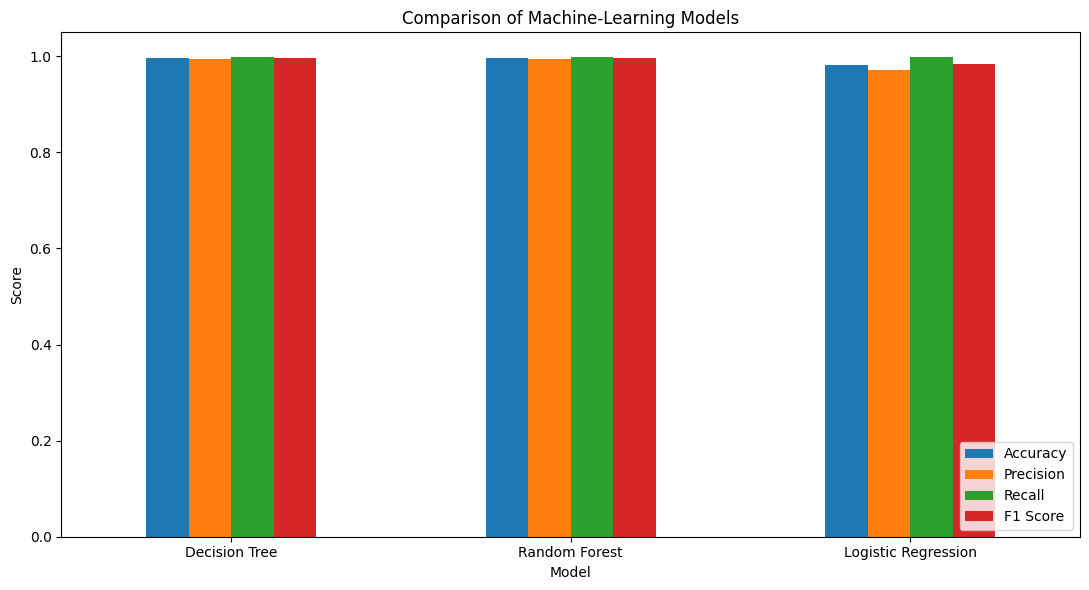

In [33]:
# Compare the models using evaluation metrics
plot_data = results_df.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1 Score"]
]

ax = plot_data.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title("Comparison of Machine-Learning Models")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [34]:
# Evaluate models specifically for the phishing class, label 0
phishing_results = []

for model_name, model in trained_models.items():

    y_pred = model.predict(X_test)

    phishing_precision = precision_score(
        y_test,
        y_pred,
        pos_label=0
    )

    phishing_recall = recall_score(
        y_test,
        y_pred,
        pos_label=0
    )

    phishing_f1 = f1_score(
        y_test,
        y_pred,
        pos_label=0
    )

    phishing_results.append({
        "Model": model_name,
        "Phishing Precision": phishing_precision,
        "Phishing Recall": phishing_recall,
        "Phishing F1 Score": phishing_f1
    })

phishing_results_df = pd.DataFrame(
    phishing_results
).sort_values(
    by="Phishing F1 Score",
    ascending=False
).reset_index(drop=True)

display_phishing_results = phishing_results_df.copy()

for column in [
    "Phishing Precision",
    "Phishing Recall",
    "Phishing F1 Score"
]:
    display_phishing_results[column] = (
        display_phishing_results[column] * 100
    ).round(2)

display(display_phishing_results)

,Model,Phishing Precision,Phishing Recall,Phishing F1 Score
0,Decision Tree,99.88,99.37,99.62
1,Random Forest,99.83,99.35,99.59
2,Logistic Regression,99.79,96.01,97.87


In [35]:
for model_name, model in trained_models.items():

    print("=" * 75)
    print(model_name)
    print("=" * 75)

    y_pred = model.predict(X_test)

    print(
        classification_report(
            y_test,
            y_pred,
            target_names=[
                "Phishing",
                "Legitimate"
            ],
            digits=4
        )
    )

Logistic Regression
              precision    recall  f1-score   support

    Phishing     0.9979    0.9601    0.9787     20189
  Legitimate     0.9710    0.9985    0.9846     26970

    accuracy                         0.9821     47159
   macro avg     0.9845    0.9793    0.9816     47159
weighted avg     0.9825    0.9821    0.9820     47159

Decision Tree
              precision    recall  f1-score   support

    Phishing     0.9988    0.9937    0.9962     20189
  Legitimate     0.9953    0.9991    0.9972     26970

    accuracy                         0.9968     47159
   macro avg     0.9970    0.9964    0.9967     47159
weighted avg     0.9968    0.9968    0.9968     47159

Random Forest
              precision    recall  f1-score   support

    Phishing     0.9983    0.9935    0.9959     20189
  Legitimate     0.9952    0.9987    0.9969     26970

    accuracy                         0.9965     47159
   macro avg     0.9967    0.9961    0.9964     47159
weighted avg     0.9965   

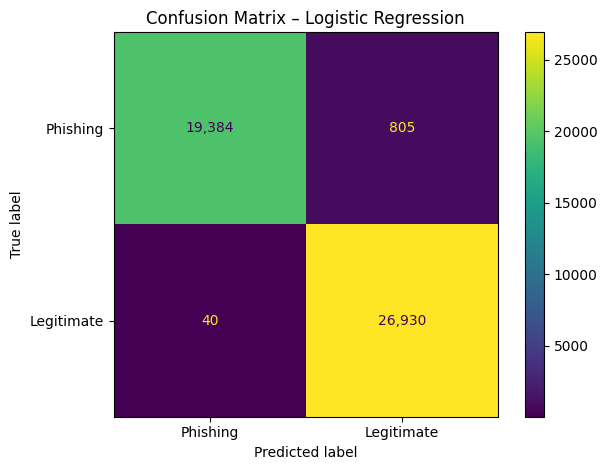

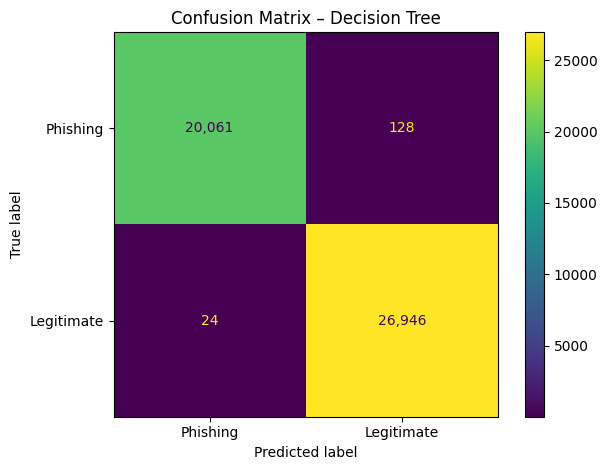

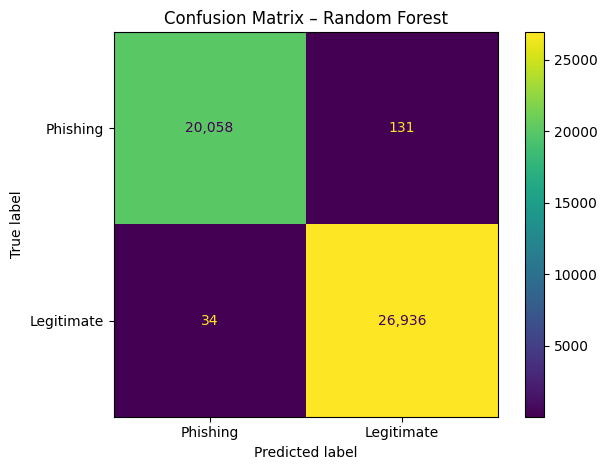

In [36]:
for model_name, model in trained_models.items():

    y_pred = model.predict(X_test)

    cm = confusion_matrix(
        y_test,
        y_pred,
        labels=[0, 1]
    )

    display_matrix = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=[
            "Phishing",
            "Legitimate"
        ]
    )

    display_matrix.plot(
        values_format=",d"
    )

    plt.title(
        f"Confusion Matrix – {model_name}"
    )

    plt.tight_layout()
    plt.show()

In [37]:
error_results = []

for model_name, model in trained_models.items():

    y_pred = model.predict(X_test)

    cm = confusion_matrix(
        y_test,
        y_pred,
        labels=[0, 1]
    )

    # Matrix layout:
    # [[actual phishing predicted phishing,
    #   actual phishing predicted legitimate],
    #  [actual legitimate predicted phishing,
    #   actual legitimate predicted legitimate]]

    phishing_correct = cm[0, 0]
    phishing_missed = cm[0, 1]
    legitimate_flagged = cm[1, 0]
    legitimate_correct = cm[1, 1]

    error_results.append({
        "Model": model_name,
        "Correctly Detected Phishing": phishing_correct,
        "Missed Phishing URLs": phishing_missed,
        "Legitimate URLs Flagged as Phishing":
            legitimate_flagged,
        "Correctly Detected Legitimate":
            legitimate_correct
    })

error_results_df = pd.DataFrame(error_results)

display(error_results_df)

,Model,Correctly Detected Phishing,Missed Phishing URLs,Legitimate URLs Flagged as Phishing,Correctly Detected Legitimate
0,Logistic Regression,19384,805,40,26930
1,Decision Tree,20061,128,24,26946
2,Random Forest,20058,131,34,26936


##Final Model Selection

The Decision Tree was selected as the final model. It achieved the lowest number of missed phishing URLs while also generating fewer false phishing warnings than the other evaluated models. This was considered particularly important because classifying a phishing URL as legitimate represents the greatest security risk.

Although Random Forest achieved very similar overall performance, the Decision Tree provided slightly better phishing detection results and a simpler, more interpretable model suitable for deployment.

In [38]:
# Select the final Decision Tree model
final_model_name = "Decision Tree"
final_model = trained_models[final_model_name]

print("Selected final model:", final_model_name)

Selected final model: Decision Tree


In [39]:
# Extract feature importance from the selected Decision Tree
feature_importance_df = pd.DataFrame({
    "Feature": url_features,
    "Importance": final_model.feature_importances_
}).sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

display(feature_importance_df)

,Feature,Importance
0,IsHTTPS,3.437916e-01
1,NoOfDegitsInURL,3.358325e-01
2,URLLength,1.589539e-01
3,DomainLength,9.934314e-02
4,NoOfSubDomain,6.060006e-02
5,TLDLength,1.250153e-03
6,DegitRatioInURL,2.285438e-04
7,NoOfQMarkInURL,2.778298e-19
8,HasObfuscation,0.000000e+00
9,IsDomainIP,0.000000e+00


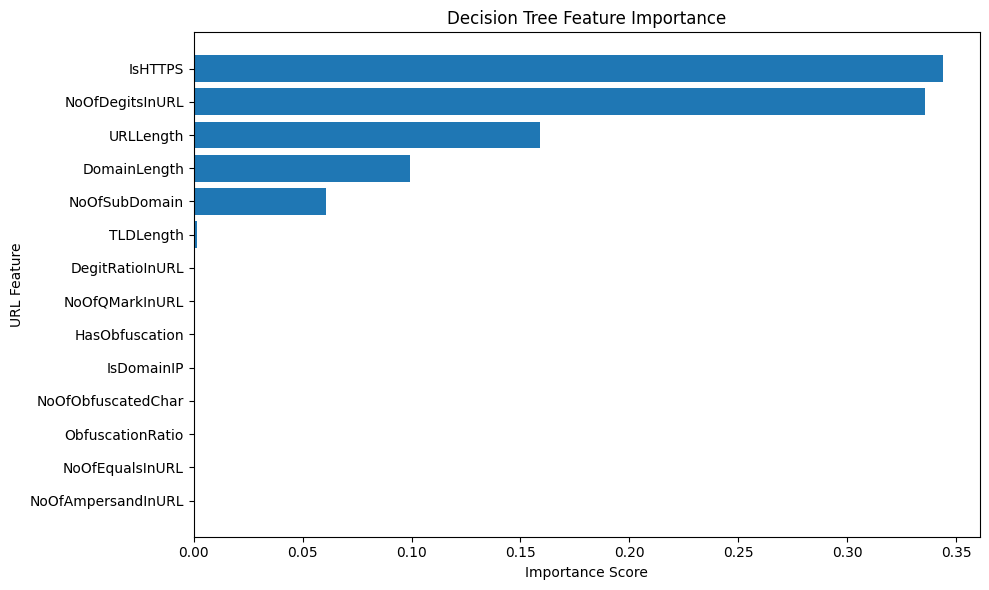

In [40]:
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance_df["Feature"][::-1],
    feature_importance_df["Importance"][::-1]
)

plt.title("Decision Tree Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("URL Feature")
plt.tight_layout()
plt.show()

In [41]:
# Save the trained Decision Tree model
with open("url_model.pkl", "wb") as model_file:
    pickle.dump(final_model, model_file)

# Save the exact feature order
with open("url_features.pkl", "wb") as feature_file:
    pickle.dump(url_features, feature_file)

print("Saved files:")
print("- url_model.pkl")
print("- url_features.pkl")

Saved files:
- url_model.pkl
- url_features.pkl


In [42]:
# Reload the saved files to confirm they work
with open("url_model.pkl", "rb") as model_file:
    loaded_model = pickle.load(model_file)

with open("url_features.pkl", "rb") as feature_file:
    loaded_features = pickle.load(feature_file)

print("Loaded model:", type(loaded_model).__name__)
print("Loaded features:", loaded_features)

Loaded model: DecisionTreeClassifier
Loaded features: ['URLLength', 'DomainLength', 'IsDomainIP', 'TLDLength', 'NoOfSubDomain', 'HasObfuscation', 'NoOfObfuscatedChar', 'ObfuscationRatio', 'NoOfDegitsInURL', 'DegitRatioInURL', 'NoOfEqualsInURL', 'NoOfQMarkInURL', 'NoOfAmpersandInURL', 'IsHTTPS']


In [52]:
def predict_url(url, model, feature_order):
    """
    Extract URL features and return the prediction
    with class probabilities.
    """

    extracted_features = extract_url_features(
        url,
        feature_order
    )

    prediction = model.predict(
        extracted_features
    )[0]

    probabilities = model.predict_proba(
        extracted_features
    )[0]

    class_probabilities = dict(
        zip(model.classes_, probabilities)
    )

    result = {
        "URL": url,
        "Prediction Code": int(prediction),
        "Prediction": (
            "Legitimate"
            if prediction == 1
            else "Phishing"
        ),
        "Phishing Probability": float(
            class_probabilities.get(0, 0)
        ),
        "Legitimate Probability": float(
            class_probabilities.get(1, 0)
        )
    }

    return result

In [53]:
test_urls = [
    "https://www.google.com",
    "https://www.microsoft.com",
    "http://192.168.1.1/login"
]

for url in test_urls:
    result = predict_url(
        url,
        loaded_model,
        loaded_features
    )

    print("=" * 70)

    for key, value in result.items():
        if "Probability" in key:
            print(f"{key}: {value:.2%}")
        else:
            print(f"{key}: {value}")

URL: https://www.google.com
Prediction Code: 1
Prediction: Legitimate
Phishing Probability: 0.27%
Legitimate Probability: 99.73%
URL: https://www.microsoft.com
Prediction Code: 1
Prediction: Legitimate
Phishing Probability: 0.19%
Legitimate Probability: 99.81%
URL: http://192.168.1.1/login
Prediction Code: 0
Prediction: Phishing
Phishing Probability: 100.00%
Legitimate Probability: 0.00%


In [46]:
from google.colab import files

files.download("url_model.pkl")
files.download("url_features.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>